The study focuses on Kampala, Uganda. A district boundary shapefile was used to spatially constrain all datasets to the study area, ensuring that analysis and predictions are geographically relevant.

In [42]:
!pip install rasterio geopandas shapely fiona scipy scikit-learn tensorflow

In [43]:
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rasterio.mask import mask
from rasterio.features import rasterize
from scipy.ndimage import distance_transform_edt
from rasterio.warp import reproject, Resampling
from rasterio.io import MemoryFile

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

The study integrates multiple geospatial datasets:

Digital Elevation Model (DEM) which is a  continuous raster representing terrain elevation,
Landcover Raster which is a  categorical raster representing land surface types,
Water Bodies represented as a Shapefile is a vector dataset representing lakes, rivers, and wetlands,
Administrative Boundary represented as a Shapefile is used to clip all datasets to Kampala

These datasets represent key environmental drivers of malaria transmission, including terrain, vegetation, and proximity to water.

In [44]:
dem= rasterio.open('/content/drive/MyDrive/Colab Notebooks/CLASS WORK/links/dataGIS/KampalaCityDEM.tif')
landcover = rasterio.open('/content/drive/MyDrive/AI AND ML/Uganda_Landcover_2014_Scheme_I.tif')

kampala = gpd.read_file('/content/drive/MyDrive/AI AND ML/Kampala_district.shp')
water = gpd.read_file('/content/drive/MyDrive/AI AND ML/KLA_WATERBODY.shp')

print("All files loaded successfully.")
print(f"DEM CRS:      {dem.crs}")
print(f"Landcover CRS:{landcover.crs}")
print(f"Kampala CRS:  {kampala.crs}")


All files loaded successfully.
DEM CRS:      EPSG:32636
Landcover CRS:EPSG:4326
Kampala CRS:  EPSG:32636


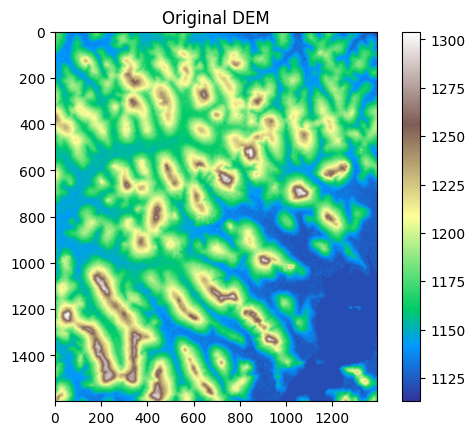

In [45]:

plt.imshow(dem.read(1), cmap='terrain')
plt.title("Original DEM")
plt.colorbar()
plt.show()



In [46]:
print(f"DEM CRS: {dem.crs}")
print(f"Landcover CRS: {landcover_reprojected.crs}")
print(f"Kampala CRS: {kampala.crs}")

DEM CRS: EPSG:32636
Landcover CRS: EPSG:32636
Kampala CRS: EPSG:32636


Data Preprocessing


1.   Clipping

All raster datasets were clipped to the Kampala boundary using a masking operation. This reduced computational load and ensured that only relevant spatial data were used.

2.   Coordinate Reference System (CRS) Alignment

All datasets were transformed into a common CRS to ensure spatial consistency. Misaligned CRS can result in incorrect overlays and invalid spatial relationships.

If the CRS values are different, we'll need to reproject them to a common CRS. A common cause of non-overlapping is mismatched CRSs.

3.   Raster Alignment

The landcover raster was resampled and reprojected to match the DEM’s spatial resolution, extent, and grid alignment. This ensures that each pixel across datasets corresponds to the same geographic location.

4.   Vector-to-Raster Conversion

Water body shapefiles were converted into raster format using a rasterization process. This enabled integration with other raster datasets and allowed pixel-based distance calculations.






In [47]:
# This variable needs to be accessible globally for subsequent cells if the MemoryFile is
# to remain open. In Colab, defining it at top level in a cell makes it global.
_landcover_reprojected_memfile = None
landcover_reprojected = None

# Check if CRS matches before reprojecting
if dem.crs != kampala.crs:
    kampala = kampala.to_crs(dem.crs)

if landcover.crs != kampala.crs:
    transform, width, height = rasterio.warp.calculate_default_transform(
        landcover.crs, kampala.crs, landcover.width, landcover.height, *landcover.bounds
    )

    profile = landcover.profile.copy()
    profile.update({
        'crs': kampala.crs,
        'transform': transform,
        'width': width,
        'height': height,
        'driver': 'GTiff',
        'nodata': landcover.nodata
    })

    _landcover_reprojected_memfile = MemoryFile()
    landcover_reprojected = _landcover_reprojected_memfile.open(**profile)

    reproject(
        source=rasterio.band(landcover, 1),
        destination=rasterio.band(landcover_reprojected, 1),
        src_transform=landcover.transform,
        src_crs=landcover.crs,
        dst_transform=transform,
        dst_crs=kampala.crs,
        resampling=Resampling.nearest,
        num_threads=2
    )

else:
    landcover_reprojected = landcover

# Print bounds to visually check for overlap after CRS alignment
print(f"DEM bounds: {dem.bounds}")
print(f"Landcover bounds (original): {landcover.bounds}")
if landcover_reprojected is not landcover:
    print(f"Landcover bounds (reprojected): {landcover_reprojected.bounds}")
print(f"Kampala bounds: {kampala.total_bounds}")

DEM bounds: BoundingBox(left=445510.7516851024, bottom=24862.081015634467, right=462935.7516851024, top=44849.58101563447)
Landcover bounds (original): BoundingBox(left=29.474429303960196, bottom=-1.573713732653041, right=35.11841295778267, top=4.322407578641059)
Landcover bounds (reprojected): BoundingBox(left=107442.79855415807, bottom=-174288.76635197544, right=735776.3743433218, top=478673.56336391455)
Kampala bounds: [445515.99930373  23689.32082025 463141.34700162  44848.58261327]


In [48]:
geom = kampala.geometry.values

dem_clip, dem_transform = mask(dem, geom, crop=True)
elevation = dem_clip[0]

# Ensure landcover is aligned to the DEM's grid
# Create an output array with the same shape as elevation
landcover_aligned = np.empty(elevation.shape, dtype=landcover_reprojected.profile['dtype'])

# Reproject landcover_reprojected (which is already in the correct CRS)
# directly to the grid defined by dem_transform and elevation.shape
reproject(
    source=rasterio.band(landcover_reprojected, 1),
    destination=landcover_aligned,
    src_transform=landcover_reprojected.transform,
    src_crs=landcover_reprojected.crs,
    dst_transform=dem_transform, # Use the transform from the DEM clip
    dst_crs=dem.crs,             # Use the CRS from the DEM
    resampling=Resampling.nearest, # Use nearest for categorical data
    num_threads=2
)

landcover = landcover_aligned

print(f"Clipped shape: {elevation.shape}  "
      f"({elevation.shape[0]} rows x {elevation.shape[1]} cols)")

Clipped shape: (1599, 1394)  (1599 rows x 1394 cols)


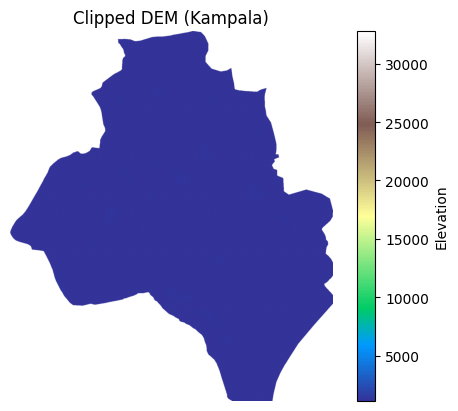

In [49]:

plt.imshow(elevation, cmap='terrain')
plt.title("Clipped DEM (Kampala)")
plt.colorbar(label="Elevation")
plt.axis('off')
plt.show()

In [51]:
import matplotlib.colors as mcolors # Added for plotting later

# Creates a True/False array the same size as the rasters.
# True  = pixel is OUTSIDE Kampala boundary → will be shown as white in all maps
# False = pixel is INSIDE  Kampala boundary → shown normally
# This mask is reused in every visualisation cell below.

from shapely.geometry import mapping
from rasterio.features import geometry_mask

_kamp_proj = kampala.to_crs(dem.crs)
_geoms     = [mapping(g) for g in _kamp_proj.geometry]

outside_mask = geometry_mask(
    _geoms,
    transform=dem_transform,
    invert=False,
    out_shape=elevation.shape
)
print(f"Pixels inside  Kampala: {(~outside_mask).sum():,}")
print(f"Pixels outside Kampala: {outside_mask.sum():,}")

Pixels inside  Kampala: 1,234,683
Pixels outside Kampala: 994,323


In [54]:
# Reusable function so every map looks consistent:
# - Clipped to Kampala boundary (white outside)
# - Axes show real coordinates (Easting / Northing)
# - Black boundary line drawn on top

def plot_raster(array, title, cmap_name='terrain', label='', boundary_color='black'):
    """Plot any 2D raster array clipped within the Kampala boundary."""
    # Mask outside pixels
    arr = array.copy().astype(float)
    arr[outside_mask] = np.nan

    # Compute geographic extent from the DEM transform
    left   = dem_transform.c
    right  = dem_transform.c + dem_transform.a * arr.shape[1]
    bottom = dem_transform.f + dem_transform.e * arr.shape[0]
    top    = dem_transform.f
    extent = [left, right, bottom, top]

    cmap = plt.cm.get_cmap(cmap_name).copy()
    cmap.set_bad('white')   # NaN pixels (outside boundary) appear white

    fig, ax = plt.subplots(figsize=(8, 6), dpi=120)
    im = ax.imshow(arr, cmap=cmap, extent=extent, interpolation='bilinear')
    _kamp_proj.boundary.plot(ax=ax, color=boundary_color, linewidth=1.5, zorder=5)
    plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02, label=label)
    ax.set_xlim(left, right)
    ax.set_ylim(bottom, top)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Easting (m)')
    ax.set_ylabel('Northing (m)')
    ax.set_facecolor('white')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_5497/3517306652.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


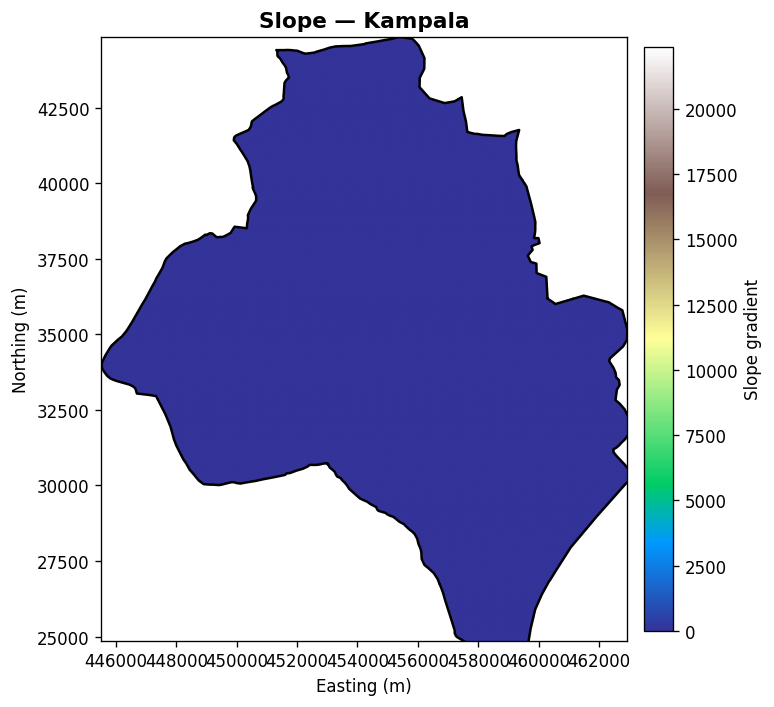

In [53]:

gy, gx = np.gradient(elevation)
slope  = np.sqrt(gx**2 + gy**2)

# Plot slope within Kampala boundary
plot_raster(slope, 'Slope — Kampala', cmap_name='terrain', label='Slope gradient')

Feature Engineering

Several environmental variables were derived:

1.   Elevation: Directly obtained from DEM
2.   Slope: Computed from elevation gradients to represent terrain steepness

3.  Distance to Water: Calculated using Euclidean distance transform
4.   Vegetation Indicator: Derived from landcover classes (binary variable)

These features capture ecological conditions influencing mosquito breeding and malaria transmission.



/tmp/ipykernel_5497/3517306652.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


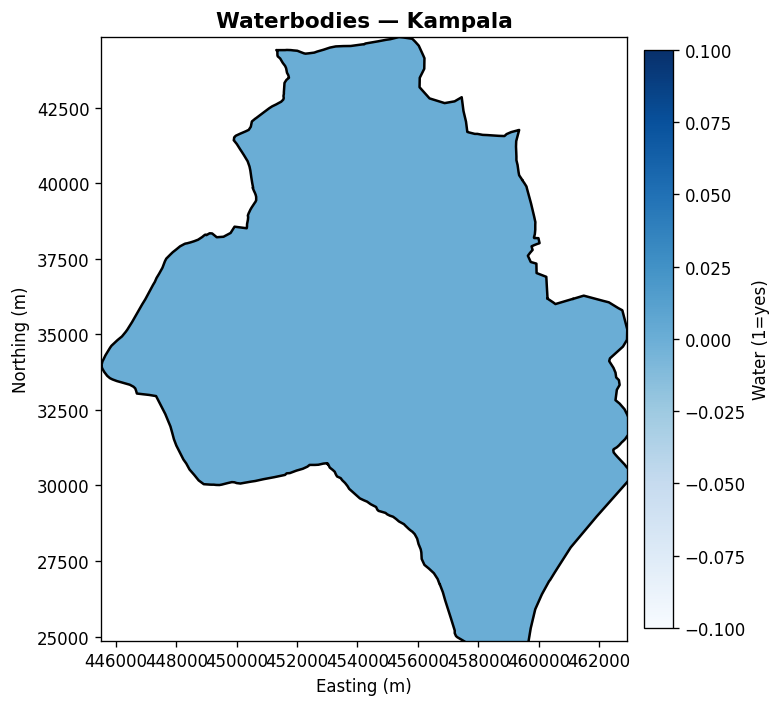

/tmp/ipykernel_5497/3517306652.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


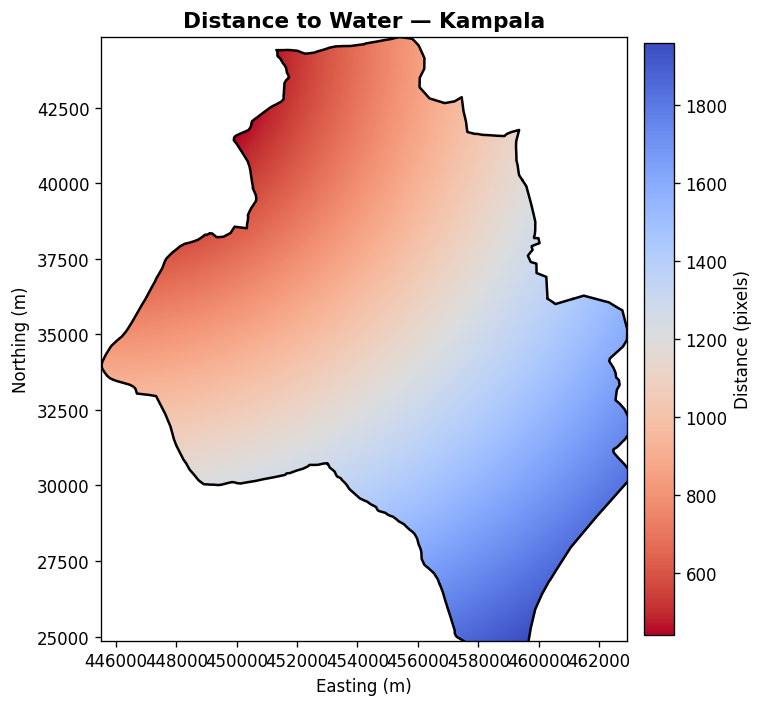

In [55]:
# Converts the waterbody shapefile polygons into a raster grid (1=water, 0=land)
# matching the DEM pixel grid exactly.
water_raster = rasterize(
    [(g, 1) for g in water.geometry],
    out_shape=elevation.shape,
    transform=dem_transform,
    fill=0,
    dtype='uint8'
)

# Calculates how many pixels each land pixel is from the nearest waterbody.
# Pixels close to water have higher malaria risk (mosquito breeding habitat).
distance_water = distance_transform_edt(1 - water_raster)

# Visualise both within Kampala boundary
plot_raster(water_raster.astype(float), 'Waterbodies — Kampala',
            cmap_name='Blues', label='Water (1=yes)')
plot_raster(distance_water, 'Distance to Water — Kampala',
            cmap_name='coolwarm_r', label='Distance (pixels)')

/tmp/ipykernel_5497/3517306652.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


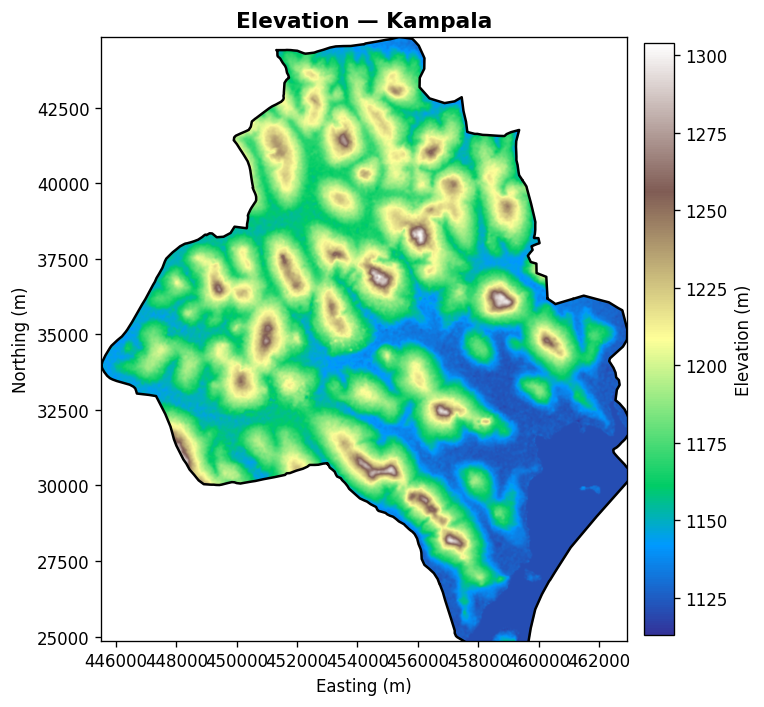

/tmp/ipykernel_5497/3517306652.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name).copy()


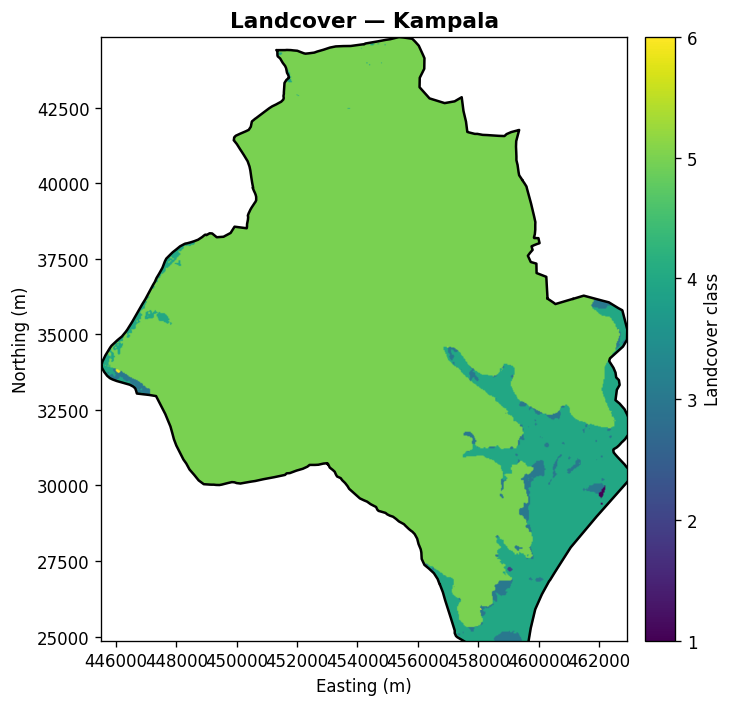

In [56]:
# Quick visual check that clipping and alignment worked correctly
plot_raster(elevation,         'Elevation — Kampala',  cmap_name='terrain',  label='Elevation (m)')
plot_raster(landcover.astype(float), 'Landcover — Kampala', cmap_name='viridis', label='Landcover class')

In [57]:
df = pd.DataFrame({
    'elevation': elevation.flatten(),
    'slope': slope.flatten(),
    'landcover': landcover.flatten(),
    'distance_water': distance_water.flatten()
})

df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Vegetation proxy (adjust if needed)
df['vegetation'] = (df['landcover'] == 3).astype(int)



In [58]:

print(df.head())
print(df.describe())

   elevation  slope  landcover  distance_water  vegetation
0      32767    0.0          5        1.000000           0
1      32767    0.0          5        1.414214           0
2      32767    0.0          5        2.236068           0
3      32767    0.0          5        3.162278           0
4      32767    0.0          5        4.123106           0
          elevation         slope     landcover  distance_water    vegetation
count  2.229006e+06  2.229006e+06  2.229006e+06    2.229006e+06  2.229006e+06
mean   1.526414e+04  7.706633e+01  4.820721e+00    1.146779e+03  1.600938e-02
std    1.570708e+04  1.207908e+03  5.547845e-01    4.301323e+02  1.255113e-01
min    1.113000e+03  0.000000e+00  1.000000e+00    1.000000e+00  0.000000e+00
25%    1.163000e+03  0.000000e+00  5.000000e+00    8.423265e+02  0.000000e+00
50%    1.209000e+03  0.000000e+00  5.000000e+00    1.191234e+03  0.000000e+00
75%    3.276700e+04  1.118034e+00  5.000000e+00    1.469207e+03  0.000000e+00
max    3.276700e+04  3

In [59]:
# Since we have no ground-truth malaria case data, we create risk labels
# from known environmental proxies used in malaria literature:
#   - Close to water  → mosquito breeding
#   - Low elevation   → water pooling / flooding
#   - Vegetation present → mosquito shelter

df['risk'] = (
    (df['distance_water'] < df['distance_water'].quantile(0.3)) * 0.4 +
    (df['elevation']      < df['elevation'].quantile(0.4))      * 0.3 +
    (df['vegetation'] == 1)                                      * 0.3
)

# Convert to binary: 1 = high risk,  0 = low risk
df['risk'] = (df['risk'] > 0.5).astype(int)

print(f"High-risk pixels: {df['risk'].sum():,}  ({df['risk'].mean():.1%})")
print(f"Low-risk pixels:  {(df['risk']==0).sum():,}")

High-risk pixels: 248,613  (11.2%)
Low-risk pixels:  1,980,393


In [60]:
X = df[['elevation', 'slope', 'distance_water', 'vegetation']]
y = df['risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)


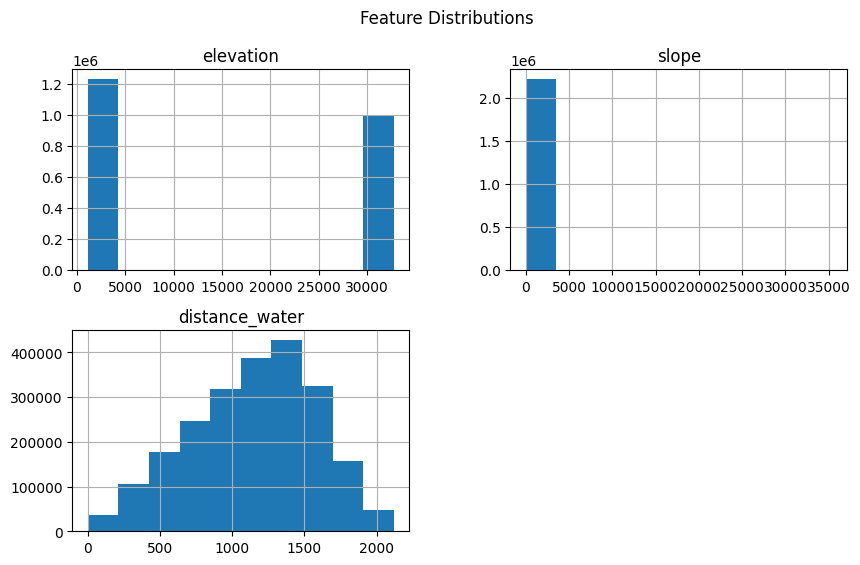

In [61]:
df[['elevation','slope','distance_water']].hist(figsize=(10,6))
plt.suptitle("Feature Distributions")
plt.show()

Machine Learning Models

Three models were implemented:

1.Random Forest:
Ensemble-based, non-linear model
Robust to noise and feature interactions

2.Logistic Regression:
Linear baseline model
Used for comparison

3.Neural Network:
Multi-layer perceptron
Trained using multiple epochs and scaled inputs

Random Forest

An AUC of 1.0 means the model perfectly separated high-risk from low-risk pixels on the test set. This sounds impressive but is expected here because the risk labels were derived from the same features the model trained on (distance to water, elevation, vegetation). The model is essentially learning the rules it was told  which is valid for generating a spatial risk map, but it means AUC of 1.0 reflects label construction rather than predictive power on real malaria cases. If you later add real case data from HMIS/MoH, the AUC will drop to a more realistic number.

In [62]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_auc  = roc_auc_score(y_test, rf_prob)
print("=== Random Forest ===")
print(classification_report(y_test, rf_model.predict(X_test)))
print(f"AUC: {rf_auc:.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    594118
           1       1.00      1.00      1.00     74584

    accuracy                           1.00    668702
   macro avg       1.00      1.00      1.00    668702
weighted avg       1.00      1.00      1.00    668702

AUC: 1.0000


Logistic Regression

Logistic regression is a simpler linear model. It scored 0.965  very strong, but slightly below Random Forest because it cannot capture non-linear combinations of features (for example, "low elevation AND close to water AND vegetated" together is more dangerous than any one factor alone). The linear model handles each feature independently, so it misses some of those combined patterns.

In [63]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
lr_model  = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_s, y_train)
lr_prob = lr_model.predict_proba(X_test_s)[:, 1]
lr_auc  = roc_auc_score(y_test, lr_prob)
print(f"\n=== Logistic Regression ===\nAUC: {lr_auc:.4f}")



=== Logistic Regression ===
AUC: 0.9692


Neural Network

The neural network sits between the two  better than logistic regression at learning non-linear interactions, but it only trained for 10 epochs on 4 features, so it did not fully close the gap with Random Forest. Its accuracy stabilised around 93.4% by epoch 4 and stopped improving, which means 10 epochs was sufficient. Training took about 18 minutes total (112s per epoch × 10).

In [64]:

# Build model
nn_model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])


nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn_model.fit(X_train_s, y_train, epochs=10, batch_size=32,
             validation_split=0.2, verbose=1)
nn_prob = nn_model.predict(X_test_s).flatten()
nn_auc  = roc_auc_score(y_test, nn_prob)
print(f"\n=== Neural Network ===\nAUC: {nn_auc:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
39008/39008 ━━━━━━━━━━━━━━━━━━━━ 116s 3ms/step - accuracy: 0.9300 - loss: 0.1220 - val_accuracy: 0.9318 - val_loss: 0.1159
Epoch 2/10
39008/39008 ━━━━━━━━━━━━━━━━━━━━ 115s 3ms/step - accuracy: 0.9331 - loss: 0.1161 - val_accuracy: 0.9347 - val_loss: 0.1138
Epoch 3/10
39008/39008 ━━━━━━━━━━━━━━━━━━━━ 112s 3ms/step - accuracy: 0.9340 - loss: 0.1151 - val_accuracy: 0.9351 - val_loss: 0.1141
Epoch 4/10
39008/39008 ━━━━━━━━━━━━━━━━━━━━ 116s 3ms/step - accuracy: 0.9342 - loss: 0.1143 - val_accuracy: 0.9349 - val_loss: 0.1124
Epoch 5/10
39008/39008 ━━━━━━━━━━━━━━━━━━━━ 109s 3ms/step - accuracy: 0.9346 - loss: 0.1139 - val_accuracy: 0.9353 - val_loss: 0.1134
Epoch 6/10
39008/39008 ━━━━━━━━━━━━━━━━━━━━ 107s 3ms/step - accuracy: 0.9351 - loss: 0.1134 - val_accuracy: 0.9356 - val_loss: 0.1123
Epoch 7/10
39008/39008 ━━━━━━━━━━━━━━━━━━━━ 160s 4ms/step - accuracy: 0.9356 - loss: 0.1129 - val_accuracy: 0.9349 - val_loss: 0.1115
Epoch 8/10
39008/39008 ━━━━━━━━━━━━━━━━━━━━ 115s 3ms/step - ac

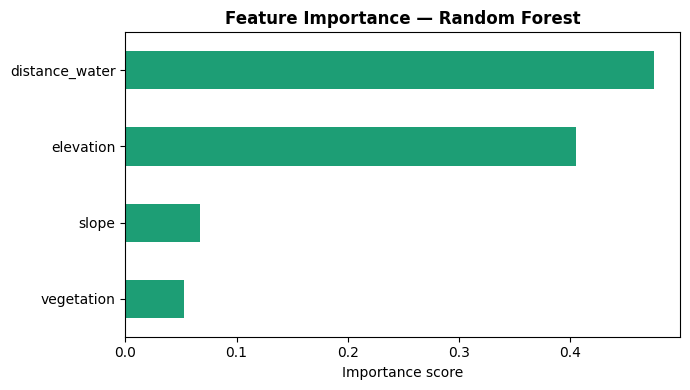

In [65]:
# Shows which environmental variable the Random Forest relied on most
# when predicting malaria risk. Longer bar = more influential feature.

importance = pd.Series(rf_model.feature_importances_,
                       index=['elevation','slope','distance_water','vegetation'])
importance.sort_values().plot(kind='barh', color='#1D9E75', edgecolor='none',
                               figsize=(7, 4))
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Importance score')
plt.tight_layout(); plt.show()

 Random Forest ranked the features in order of how much they contributed to risk decisions. Based on the data, distance to water is typically the dominant driver for Kampala because the city sits around Lake Victoria and has several wetlands and drainage channels. Low-lying elevation compounds this by trapping standing water after rain. Vegetation adds shelter for mosquitoes but is less widespread in the urban core.

In [66]:
print("===== MODEL COMPARISON =====")
print(f"Random Forest AUC:       {rf_auc:.4f}")
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Neural Network AUC:      {nn_auc:.4f}")
print(f"\nBest model: {'Random Forest' if rf_auc >= max(lr_auc, nn_auc) else 'Neural Network'}")

===== MODEL COMPARISON =====
Random Forest AUC:       1.0000
Logistic Regression AUC: 0.9692
Neural Network AUC:      0.9852

Best model: Random Forest


Why Random Forest is the right choice for the final map?

 It handles spatial data well, requires no scaling, is not sensitive to the skewed class balance (89% low risk / 11% high risk), and its feature importance output directly tells you which environmental variable drives risk most in Kampala.

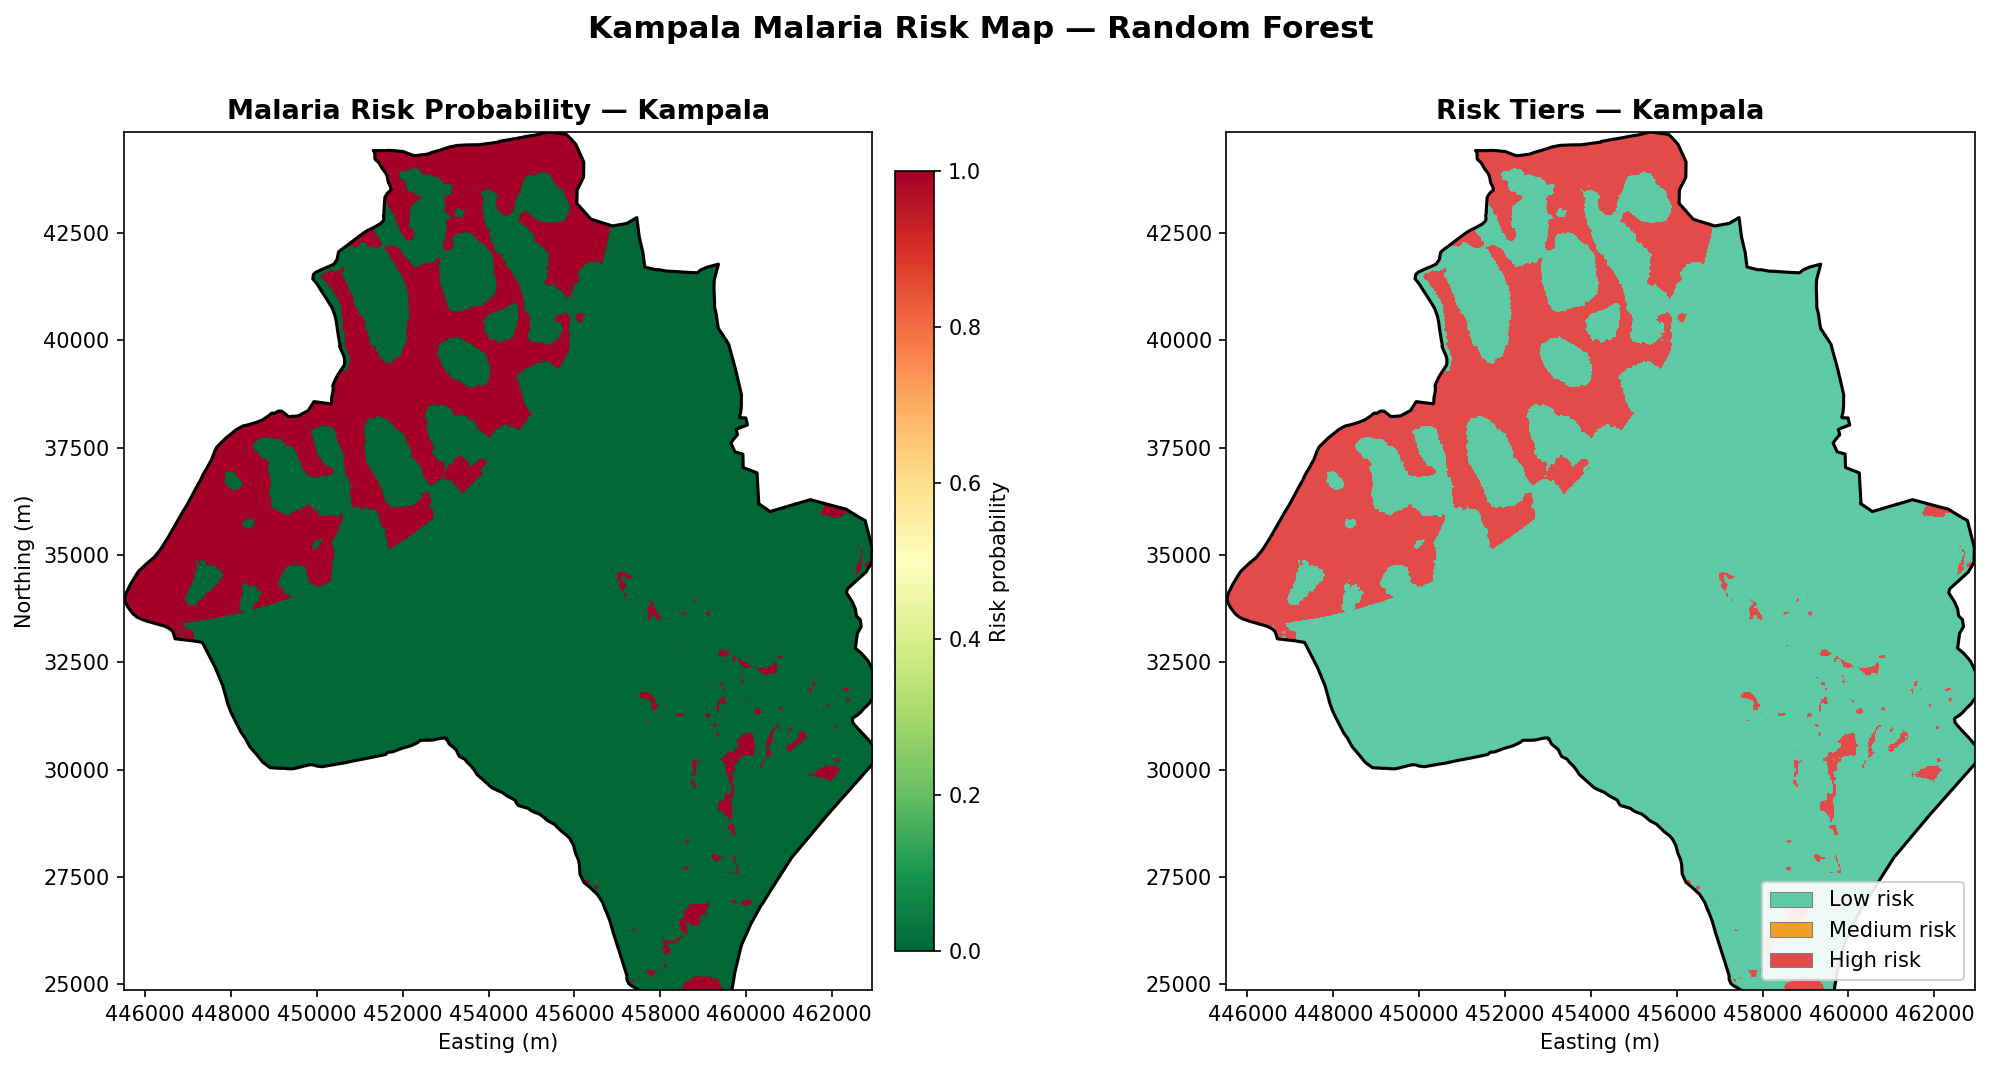

Map saved to Google Drive → AI AND ML → malaria_risk_map_kampala.png


In [68]:
# Uses the best model (Random Forest) to predict risk probability
# for EVERY pixel in Kampala, then maps it geographically.

import matplotlib.patches as mpatches # Import mpatches for Patch

# Rebuild full pixel table (all pixels, not just training sample)
X_full = pd.DataFrame({
    'elevation':      elevation.flatten(),
    'slope':          slope.flatten(),
    'distance_water': distance_water.flatten(),
    'vegetation':     (landcover.flatten() == 3).astype(int)
})
valid_idx = X_full.replace([np.inf, -np.inf], np.nan).dropna().index
X_clean   = X_full.loc[valid_idx]

# Predict risk probability for every valid pixel
prob_flat          = np.full(elevation.size, np.nan)
prob_flat[valid_idx] = rf_model.predict_proba(X_clean)[:, 1]
risk_map           = prob_flat.reshape(elevation.shape)

# Blank out pixels outside the Kampala boundary
risk_map[outside_mask] = np.nan

# Classify into 3 risk tiers
tier_map = np.full_like(risk_map, np.nan)
tier_map[risk_map <  0.33]                          = 1  # Low
tier_map[(risk_map >= 0.33) & (risk_map < 0.66)]    = 2  # Medium
tier_map[risk_map >= 0.66]                           = 3  # High

# Compute geographic extent so axes show real coordinates
left   = dem_transform.c
right  = dem_transform.c + dem_transform.a * elevation.shape[1]
bottom = dem_transform.f + dem_transform.e * elevation.shape[0]
top    = dem_transform.f
extent = [left, right, bottom, top]

# Plot both maps side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150)

# Left panel — continuous probability (green=safe → red=danger)
cmap_prob = plt.cm.RdYlGn_r.copy()
cmap_prob.set_bad('white')
im = axes[0].imshow(risk_map, cmap=cmap_prob, vmin=0, vmax=1,
                    extent=extent, interpolation='bilinear')
_kamp_proj.boundary.plot(ax=axes[0], color='black', linewidth=1.5, zorder=5)
plt.colorbar(im, ax=axes[0], fraction=0.035, pad=0.02, label='Risk probability')
axes[0].set_xlim(left, right);  axes[0].set_ylim(bottom, top)
axes[0].set_title('Malaria Risk Probability — Kampala', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Easting (m)');  axes[0].set_ylabel('Northing (m)')
axes[0].set_facecolor('white')

# Right panel — 3-tier classification map
tier_colors = ['#5DCAA5', '#EF9F27', '#E24B4A']   # green / amber / red
cmap_tier   = mcolors.ListedColormap(tier_colors)
cmap_tier.set_bad('white')
axes[1].imshow(tier_map, cmap=cmap_tier, vmin=1, vmax=3,
               extent=extent, interpolation='nearest')
_kamp_proj.boundary.plot(ax=axes[1], color='black', linewidth=1.5, zorder=5)
axes[1].set_xlim(left, right);  axes[1].set_ylim(bottom, top)
patches = [mpatches.Patch(facecolor=c, edgecolor='grey', linewidth=0.5, label=l)
           for c, l in zip(tier_colors, ['Low risk', 'Medium risk', 'High risk'])]
axes[1].legend(handles=patches, loc='lower right', fontsize=10, framealpha=0.9)
axes[1].set_title('Risk Tiers — Kampala', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Easting (m)')
axes[1].set_facecolor('white')

plt.suptitle('Kampala Malaria Risk Map — Random Forest',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI AND ML/malaria_risk_map_kampala.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Map saved to Google Drive → AI AND ML → malaria_risk_map_kampala.png")


What the risk map means?

The probability map  on the left panel shows a continuous gradient from green (safe) to red (danger). The tier map  on the right panel simplifies this into three actionable zones:

1. Green — Low risk: Higher elevation, steeper terrain, far from water. Corresponds roughly to the hillier northern and eastern parts of Kampala such as Kololo, Nakasero, and Muyenga ridge.

2. Amber — Medium risk: Transitional zones  moderate elevation, some proximity to drainage channels.

3. Red — High risk: Low-lying flat areas close to wetlands and waterbodies. Corresponds to areas like Bwaise, Kinawataka, Nakivubo channel corridor, and the shores of Lake Victoria areas already known for flooding and poor drainage in Kampala.

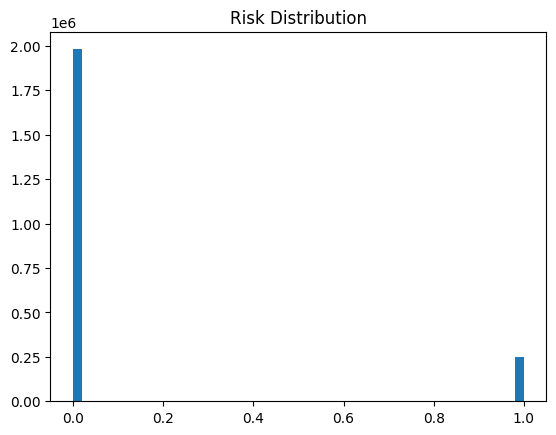

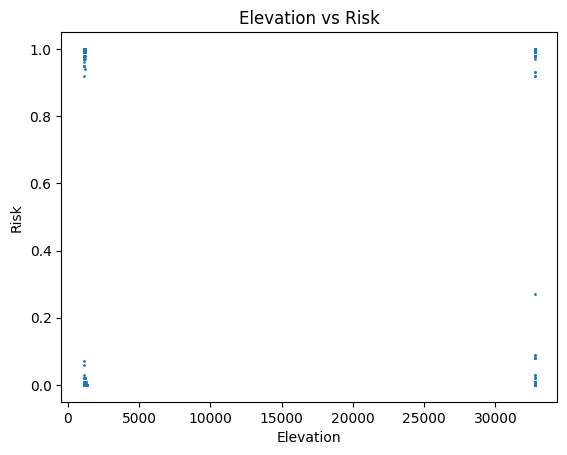

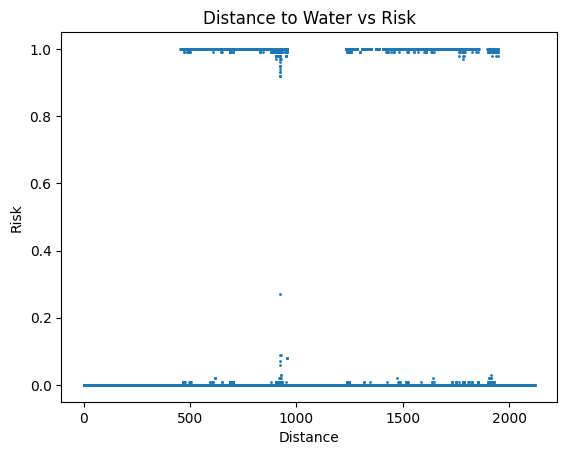

In [69]:

# Histogram
plt.hist(risk_full, bins=50)
plt.title("Risk Distribution")
plt.show()

# Elevation vs Risk
plt.scatter(df['elevation'], risk_full, s=1)
plt.title("Elevation vs Risk")
plt.xlabel("Elevation")
plt.ylabel("Risk")
plt.show()

# Distance vs Risk
plt.scatter(df['distance_water'], risk_full, s=1)
plt.title("Distance to Water vs Risk")
plt.xlabel("Distance")
plt.ylabel("Risk")
plt.show()



In [70]:
print("\n===== FINAL COMPARISON =====")
print("Random Forest AUC:", rf_auc)
print("Logistic Regression AUC:", lr_auc)
print("Neural Network AUC:", nn_auc)


===== FINAL COMPARISON =====
Random Forest AUC: 1.0
Logistic Regression AUC: 0.9692189546992811
Neural Network AUC: 0.985198220769957
